In [1]:
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")
import pandas as pd
data = pd.read_csv("data_bersih.csv")
data = data.dropna()
print(data.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Fadli\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                text  \
0  Calon Presiden Indonesia Ganjar Pranowo bersil...   
1  *KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...   
2  @ch_chotimah2 Dulu waktu AHY calon gubernur di...   
3  Sang calon presiden Indonesia, Ganjar Pranowo ...   
4  Banyak tokoh yang digadang-gadang jadi calon w...   

                                          text_clean  \
0  calon presiden indonesia ganjar pranowo bersil...   
1  kode alam dan tanda zaman siapa presiden ri ke...   
2  chchotimah dulu waktu ahy calon gubernur di dk...   
3  sang calon presiden indonesia ganjar pranowo t...   
4  banyak tokoh yang digadanggadang jadi calon wa...   

                                               token  \
0  ['calon', 'presiden', 'indonesia', 'ganjar', '...   
1  ['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...   
2  ['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...   
3  ['sang', 'calon', 'presiden', 'indonesia', 'ga...   
4  ['banyak', 'tokoh', 'yang', 'digadanggadang

In [2]:
sentiments = SentimentIntensityAnalyzer()
data["Positif"] = [sentiments.polarity_scores(i)["pos"] for i in data["text"]]
data["Negative"] = [sentiments.polarity_scores(i)["neg"] for i in data["text"]]
data["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in data["text"]]
data["Compound"] = [sentiments.polarity_scores(i)["compound"] for i in data["text"]]
data.head()

,text,text_clean,token,stop,stemmed,Positif,Negative,Neutral,Compound
0,Calon Presiden Indonesia Ganjar Pranowo bersil...,calon presiden indonesia ganjar pranowo bersil...,"['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...",0.0,0.0,1.0,0.0
1,*KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...,kode alam dan tanda zaman siapa presiden ri ke...,"['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...",0.0,0.0,1.0,0.0
2,@ch_chotimah2 Dulu waktu AHY calon gubernur di...,chchotimah dulu waktu ahy calon gubernur di dk...,"['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...",0.0,0.0,1.0,0.0
3,"Sang calon presiden Indonesia, Ganjar Pranowo ...",sang calon presiden indonesia ganjar pranowo t...,"['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...",0.0,0.0,1.0,0.0
4,Banyak tokoh yang digadang-gadang jadi calon w...,banyak tokoh yang digadanggadang jadi calon wa...,"['banyak', 'tokoh', 'yang', 'digadanggadang', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...",0.0,0.0,1.0,0.0


In [3]:
score = data["Compound"].values
sentiment = []
for i in score:
  if i >= 0.05 :
    sentiment.append('positif')
  elif i <= -0.05 :
    sentiment.append('negatif')
  else:
    sentiment.append('netral')
data["sentiment"] =  sentiment
data.head(50)

,text,text_clean,token,stop,stemmed,Positif,Negative,Neutral,Compound,sentiment
0,Calon Presiden Indonesia Ganjar Pranowo bersil...,calon presiden indonesia ganjar pranowo bersil...,"['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...",0.000,0.000,1.000,0.0000,netral
1,*KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...,kode alam dan tanda zaman siapa presiden ri ke...,"['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...",0.000,0.000,1.000,0.0000,netral
2,@ch_chotimah2 Dulu waktu AHY calon gubernur di...,chchotimah dulu waktu ahy calon gubernur di dk...,"['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...",0.000,0.000,1.000,0.0000,netral
3,"Sang calon presiden Indonesia, Ganjar Pranowo ...",sang calon presiden indonesia ganjar pranowo t...,"['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...",0.000,0.000,1.000,0.0000,netral
4,Banyak tokoh yang digadang-gadang jadi calon w...,banyak tokoh yang digadanggadang jadi calon wa...,"['banyak', 'tokoh', 'yang', 'digadanggadang', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...",0.000,0.000,1.000,0.0000,netral
5,Ganjar Pranowo mengajak partai politik penduku...,ganjar pranowo mengajak partai politik penduku...,"['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...",0.000,0.000,1.000,0.0000,netral
6,Bakal calon presiden (bacapres) dari Partai Ge...,bakal calon presiden bacapres dari partai geri...,"['bakal', 'calon', 'presiden', 'bacapres', 'da...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...",0.000,0.000,1.000,0.0000,netral
7,@yodisss Seneng bgt nih pasti masyarakat Lombo...,yodisss seneng bgt nih pasti masyarakat lombok...,"['yodisss', 'seneng', 'bgt', 'nih', 'pasti', '...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...",0.000,0.000,1.000,0.0000,netral
8,Bakal calon presiden yang juga Menteri Pertaha...,bakal calon presiden yang juga menteri pertaha...,"['bakal', 'calon', 'presiden', 'yang', 'juga',...","['bakal', 'calon', 'presiden', 'menteri', 'per...","['bakal', 'calon', 'presiden', 'menteri', 'per...",0.000,0.000,1.000,0.0000,netral
9,Mereka yg masih mempersoalkan seorang presiden...,mereka yg masih mempersoalkan seorang presiden...,"['mereka', 'yg', 'masih', 'mempersoalkan', 'se...","['yg', 'mempersoalkan', 'seorang', 'presidenca...","['yg', 'mempersoalkan', 'seorang', 'presidenca...",0.000,0.000,1.000,0.0000,netral


In [4]:
df = data

In [5]:
df = df.drop('Positif', axis=1)
df = df.drop('Negative', axis=1)
df = df.drop('Neutral', axis=1)
df = df.drop('Compound', axis=1)

In [6]:
df.head(50)

,text,text_clean,token,stop,stemmed,sentiment
0,Calon Presiden Indonesia Ganjar Pranowo bersil...,calon presiden indonesia ganjar pranowo bersil...,"['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...",netral
1,*KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...,kode alam dan tanda zaman siapa presiden ri ke...,"['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...",netral
2,@ch_chotimah2 Dulu waktu AHY calon gubernur di...,chchotimah dulu waktu ahy calon gubernur di dk...,"['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...",netral
3,"Sang calon presiden Indonesia, Ganjar Pranowo ...",sang calon presiden indonesia ganjar pranowo t...,"['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...",netral
4,Banyak tokoh yang digadang-gadang jadi calon w...,banyak tokoh yang digadanggadang jadi calon wa...,"['banyak', 'tokoh', 'yang', 'digadanggadang', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...",netral
5,Ganjar Pranowo mengajak partai politik penduku...,ganjar pranowo mengajak partai politik penduku...,"['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...",netral
6,Bakal calon presiden (bacapres) dari Partai Ge...,bakal calon presiden bacapres dari partai geri...,"['bakal', 'calon', 'presiden', 'bacapres', 'da...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...",netral
7,@yodisss Seneng bgt nih pasti masyarakat Lombo...,yodisss seneng bgt nih pasti masyarakat lombok...,"['yodisss', 'seneng', 'bgt', 'nih', 'pasti', '...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...",netral
8,Bakal calon presiden yang juga Menteri Pertaha...,bakal calon presiden yang juga menteri pertaha...,"['bakal', 'calon', 'presiden', 'yang', 'juga',...","['bakal', 'calon', 'presiden', 'menteri', 'per...","['bakal', 'calon', 'presiden', 'menteri', 'per...",netral
9,Mereka yg masih mempersoalkan seorang presiden...,mereka yg masih mempersoalkan seorang presiden...,"['mereka', 'yg', 'masih', 'mempersoalkan', 'se...","['yg', 'mempersoalkan', 'seorang', 'presidenca...","['yg', 'mempersoalkan', 'seorang', 'presidenca...",netral


In [7]:
df.to_csv("Labeling.csv", index =False)

In [8]:
data = pd.read_csv ("Labeling.csv")

In [9]:
df.head()

,text,text_clean,token,stop,stemmed,sentiment
0,Calon Presiden Indonesia Ganjar Pranowo bersil...,calon presiden indonesia ganjar pranowo bersil...,"['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...",netral
1,*KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...,kode alam dan tanda zaman siapa presiden ri ke...,"['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...",netral
2,@ch_chotimah2 Dulu waktu AHY calon gubernur di...,chchotimah dulu waktu ahy calon gubernur di dk...,"['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...",netral
3,"Sang calon presiden Indonesia, Ganjar Pranowo ...",sang calon presiden indonesia ganjar pranowo t...,"['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...",netral
4,Banyak tokoh yang digadang-gadang jadi calon w...,banyak tokoh yang digadanggadang jadi calon wa...,"['banyak', 'tokoh', 'yang', 'digadanggadang', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...",netral


In [10]:
jumlah_positif = 6
jumlah_netral = 598
jumlah_negatif = 25

In [11]:
labels = ['Positif','netral', 'Negatif']
counts = [jumlah_positif, jumlah_netral, jumlah_negatif]

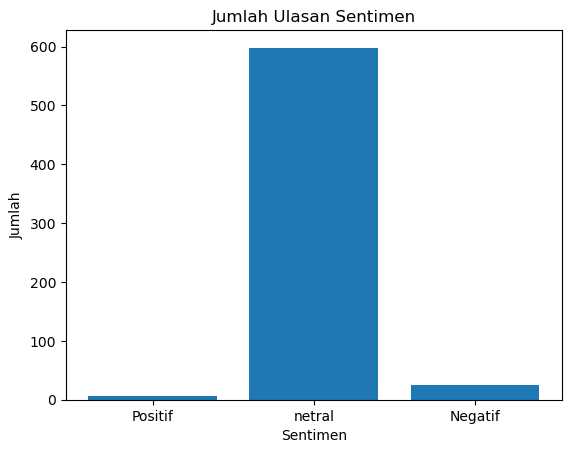

In [12]:
plt.bar(labels, counts)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.title('Jumlah Ulasan Sentimen')
plt.show()

In [14]:
panjang_train_dataset = train['Tweet'].str.len()
panjang_test_dataset = test['Tweet' ].str.len()
plt.hist(panjang_train_dataset, bins=10, label='Train tweets')
plt.hist(panjang_test_dataset, bins = 10,label='Test tweets')
plt.legend()
plt.show()

NameError: name 'train' is not defined